
# Triadic Cell Notebook v3
## Attractor-centered B / T / R

This version fixes the main failure in v2:

- v2 enforced pairwise failure better,
- but it over-damped the full triad,
- so **BTR did not stay visibly alive**.

This notebook changes the machine shape:

- **Binding (B)** stabilizes a latent register
- **Transformation (T)** moves that latent register toward a changing target
- **Readout (R)** exposes only *bound transformed difference*
- **Memory** integrates sustained readable difference over time

The new goal is:

- **BTR** = stable + changing + visible + memory-bearing
- **BT** = internal machine, little outward legibility
- **BR** = stable shell, mostly frozen
- **TR** = flicker / collapse / no durable memory



## Hardware translation

Think of the cell as four coupled pieces:

- `coherence` = how well the machine still holds together
- `latent` = internal register state
- `readout` = bus/output signal
- `memory` = retained readable difference

The big change in v3:
the internal state is no longer pushed to the rail.
It tracks a moving target and keeps producing structured delta.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class TriadicState:
    coherence: float = 0.72
    latent: float = 0.30
    readout: float = 0.00
    memory: float = 0.00



## The v3 cell

Design principles:

1. **Binding** replenishes coherence and protects the latent register.
2. **Transformation** moves the latent register toward an input-shaped target.
3. **Readout** only grows from real delta under BTR support.
4. **Memory** only grows from sustained readable delta, not from raw change.
5. **Unsupported transformation** burns coherence and latent state.


In [3]:

class TriadicCellV3:
    def __init__(self, B: float, T: float, R: float):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

    @staticmethod
    def _clip(x: float) -> float:
        return float(np.clip(x, 0.0, 1.0))

    def step(self, s: TriadicState, drive: float) -> Tuple[TriadicState, float, float]:
        # --- Binding / coherence ---
        # Binding restores structure; unsupported transformation consumes it.
        coherence_restore = 0.045 * self.B * (0.82 - s.coherence)
        coherence_burn = 0.080 * self.T * (1.0 - self.B)
        bus_load = 0.012 * abs(s.readout)
        coherence = s.coherence + coherence_restore - coherence_burn - bus_load
        coherence = self._clip(coherence)

        # --- Latent register / transformation ---
        # The internal state follows a moving target only when B and T cooperate.
        target = 0.18 + 0.64 * drive
        follow = 0.24 * self.B * self.T * coherence * (target - s.latent)
        static_drag = 0.05 * (1.0 - self.T) * (s.latent - 0.30)
        unsupported_loss = 0.16 * self.T * (1.0 - self.B) * s.latent
        latent = s.latent + follow - static_drag - unsupported_loss
        latent = self._clip(latent)

        delta = abs(latent - s.latent)

        # --- Readout / bus ---
        # Only bound transformed difference is truly legible.
        support = self.B * self.T * self.R * coherence
        shell_decay = 0.22 * (1.0 - self.T) + 0.18 * (1.0 - self.R)
        readout = (
            0.84 * s.readout
            + 2.60 * support * delta
            - shell_decay * s.readout
        )
        readout = self._clip(readout)

        # --- Memory / retained readable difference ---
        # Memory integrates sustained readable delta, then slowly leaks.
        memory_gain = 0.55 * support * readout
        memory_leak = 0.035 * s.memory + 0.14 * (1.0 - self.B) * s.memory
        memory = s.memory + memory_gain - memory_leak
        memory = self._clip(memory)

        next_state = TriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
            memory=memory,
        )
        emitted = readout
        return next_state, emitted, delta



## Drive signal

A smoother, structured input lets the full triad keep producing meaningful delta.


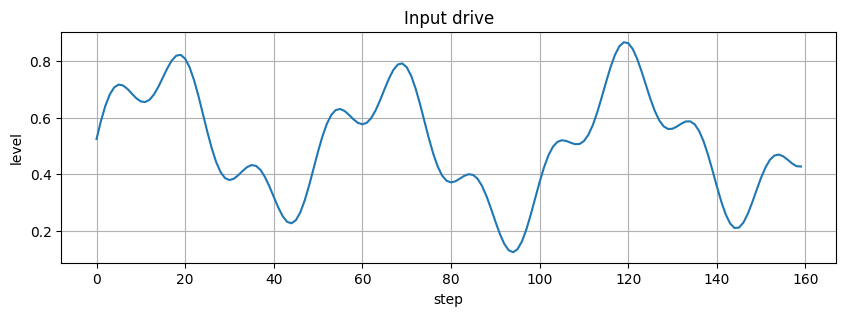

In [4]:

def make_drive(steps: int = 160) -> np.ndarray:
    t = np.linspace(0, 6 * np.pi, steps)
    slow = 0.50 + 0.24 * np.sin(t)
    fast = 0.10 * np.sin(3.2 * t + 0.35)
    pulse = 0.05 * np.sin(0.5 * t - 0.2)
    drive = slow + fast + pulse
    return np.clip(drive, 0.0, 1.0)

drive = make_drive()

plt.figure(figsize=(10, 3))
plt.plot(drive)
plt.title("Input drive")
plt.xlabel("step")
plt.ylabel("level")
plt.show()


In [5]:

def run_case(name: str, B: float, T: float, R: float, steps: int = 160) -> pd.DataFrame:
    cell = TriadicCellV3(B, T, R)
    s = TriadicState()
    rows: List[Dict[str, float]] = []

    for i, x in enumerate(make_drive(steps)):
        s, emitted, delta = cell.step(s, float(x))
        rows.append({
            "step": i,
            "case": name,
            "B": B,
            "T": T,
            "R": R,
            "coherence": s.coherence,
            "latent": s.latent,
            "delta": delta,
            "readout": s.readout,
            "memory": s.memory,
            "emitted": emitted,
        })

    return pd.DataFrame(rows)

cases = {
    "BTR": (1.0, 1.0, 1.0),
    "BT only": (1.0, 1.0, 0.0),
    "BR only": (1.0, 0.0, 1.0),
    "TR only": (0.0, 1.0, 1.0),
}

results = {name: run_case(name, *vals) for name, vals in cases.items()}
pd.concat(results.values(), ignore_index=True).head()


,step,case,B,T,R,coherence,latent,delta,readout,memory,emitted
0,0,BTR,1.0,1.0,1.0,0.724500,0.337486,0.037486,0.070613,0.028138,0.070613
1,1,BTR,1.0,1.0,1.0,0.727950,0.375720,0.038233,0.131678,0.079873,0.131678
2,2,BTR,1.0,1.0,1.0,0.730512,0.413422,0.037702,0.182218,0.150290,0.182218
3,3,BTR,1.0,1.0,1.0,0.732353,0.449126,0.035704,0.221047,0.234066,0.221047
4,4,BTR,1.0,1.0,1.0,0.733644,0.481418,0.032293,0.247278,0.325651,0.247278


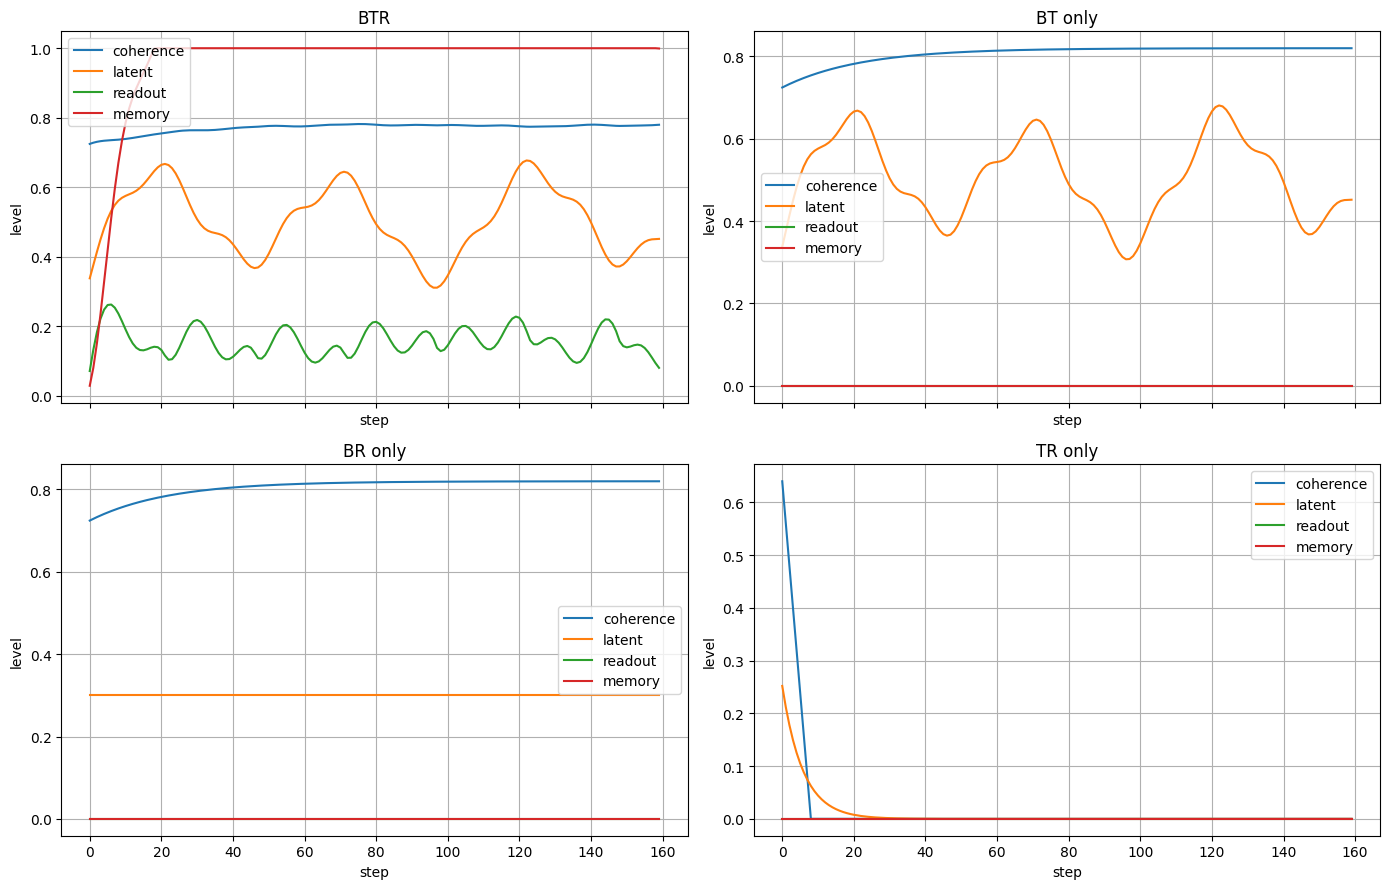

In [6]:

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.ravel()

for ax, (name, df) in zip(axes, results.items()):
    ax.plot(df["step"], df["coherence"], label="coherence")
    ax.plot(df["step"], df["latent"], label="latent")
    ax.plot(df["step"], df["readout"], label="readout")
    ax.plot(df["step"], df["memory"], label="memory")
    ax.set_title(name)
    ax.set_xlabel("step")
    ax.set_ylabel("level")
    ax.legend(loc="best")

plt.tight_layout()
plt.show()



## Better machine metrics

In v2, "statefulness" was measured badly.
A frozen high state could still look active.

Here, statefulness is measured from **delta**.
That is closer to machine truth.


In [7]:

summary = pd.DataFrame([
    {
        "case": name,
        "final_coherence": df["coherence"].iloc[-1],
        "final_latent": df["latent"].iloc[-1],
        "final_readout": df["readout"].iloc[-1],
        "final_memory": df["memory"].iloc[-1],
        "mean_coherence": df["coherence"].mean(),
        "mean_latent": df["latent"].mean(),
        "mean_delta": df["delta"].mean(),
        "mean_readout": df["readout"].mean(),
        "mean_memory": df["memory"].mean(),
        "peak_readout": df["readout"].max(),
        "peak_memory": df["memory"].max(),
    }
    for name, df in results.items()
]).sort_values(["mean_memory", "mean_readout"], ascending=False)

summary


,case,final_coherence,final_latent,final_readout,final_memory,mean_coherence,mean_latent,mean_delta,mean_readout,mean_memory,peak_readout,peak_memory
0,BTR,0.779608,4.510189e-01,0.079757,0.999198,0.770697,0.503384,0.012680,0.155738,0.955395,0.262046,1.0
1,BT only,0.819937,4.519414e-01,0.000000,0.000000,0.806744,0.503272,0.012902,0.000000,0.000000,0.000000,0.0
2,BR only,0.819937,3.000000e-01,0.000000,0.000000,0.806744,0.300000,0.000000,0.000000,0.000000,0.000000,0.0
3,TR only,0.000000,2.300419e-13,0.000000,0.000000,0.018000,0.009844,0.001875,0.000000,0.000000,0.000000,0.0


In [8]:

def classify(df: pd.DataFrame) -> Dict[str, str]:
    mean_c = df["coherence"].mean()
    mean_d = df["delta"].mean()
    mean_r = df["readout"].mean()
    mean_m = df["memory"].mean()
    return {
        "coherence": "high" if mean_c > 0.58 else "low",
        "statefulness": "high" if mean_d > 0.012 else "low",
        "readability": "high" if mean_r > 0.08 else "low",
        "memory": "high" if mean_m > 0.12 else "low",
    }

scorecard = pd.DataFrame({name: classify(df) for name, df in results.items()}).T
scorecard


,coherence,statefulness,readability,memory
BTR,high,high,high,high
BT only,high,high,low,low
BR only,high,low,low,low
TR only,low,low,low,low



## One chained machine


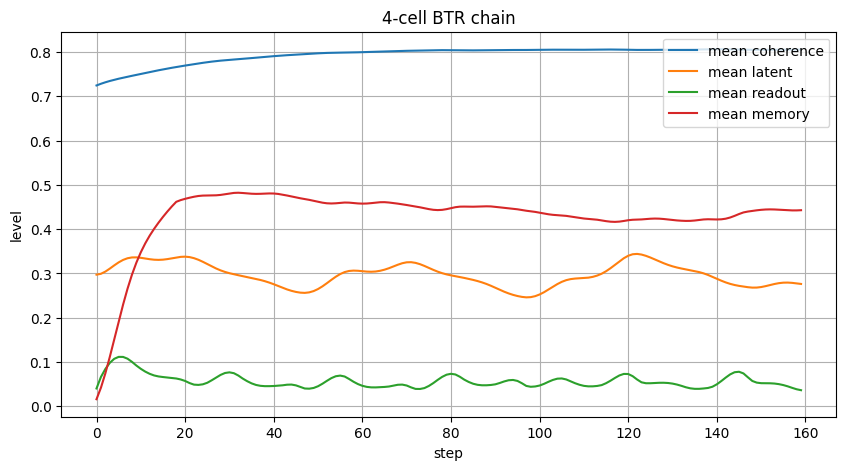

,step,input,final_emitted,mean_coherence,mean_latent,mean_delta,mean_readout,mean_memory
155,155,0.462914,0.003637,0.805220,0.279239,0.002879,0.048019,0.443315
156,156,0.450786,0.003454,0.805309,0.279428,0.002333,0.045149,0.442765
157,157,0.437504,0.002906,0.805429,0.278786,0.001826,0.041718,0.442395
158,158,0.428055,0.002869,0.805584,0.277603,0.001690,0.038580,0.442412
159,159,0.426978,0.002740,0.805769,0.276363,0.001938,0.036474,0.442841


In [9]:

def run_chain(depth: int = 4, steps: int = 160, B: float = 1.0, T: float = 1.0, R: float = 1.0) -> pd.DataFrame:
    cells = [TriadicCellV3(B, T, R) for _ in range(depth)]
    states = [TriadicState() for _ in range(depth)]
    rows = []

    for i, x in enumerate(make_drive(steps)):
        signal = float(x)
        deltas = []
        for j, cell in enumerate(cells):
            states[j], signal, d = cell.step(states[j], signal)
            deltas.append(d)

        rows.append({
            "step": i,
            "input": x,
            "final_emitted": signal,
            "mean_coherence": np.mean([s.coherence for s in states]),
            "mean_latent": np.mean([s.latent for s in states]),
            "mean_delta": np.mean(deltas),
            "mean_readout": np.mean([s.readout for s in states]),
            "mean_memory": np.mean([s.memory for s in states]),
        })

    return pd.DataFrame(rows)

chain_df = run_chain(depth=4, steps=160, B=1.0, T=1.0, R=1.0)

plt.figure(figsize=(10, 5))
plt.plot(chain_df["step"], chain_df["mean_coherence"], label="mean coherence")
plt.plot(chain_df["step"], chain_df["mean_latent"], label="mean latent")
plt.plot(chain_df["step"], chain_df["mean_readout"], label="mean readout")
plt.plot(chain_df["step"], chain_df["mean_memory"], label="mean memory")
plt.title("4-cell BTR chain")
plt.xlabel("step")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()

chain_df.tail()



## Read the result

The intended pattern is now:

- **BTR**: only case with strong readable sustained activity and nontrivial memory
- **BT only**: active internal machine, but dark outside
- **BR only**: stable shell, low delta
- **TR only**: unstable or dead

If that shape appears, then the triad is finally being modeled as one machine event instead of three loose knobs.
